Probabilidades - Aula 6
Este material é baseado no curso de Introdução a Probabilidade para ciência de dados.

### Modelos probabilísticos

* Os resultados de cada experimento parecem imprevisíveis, mas quando um grande número de experimentos é analisado, surge um padrão.
* Não podemos determinar o valor exato do resultado de um experimento, mas sim as probabilidades de cada resultado possível.

**Exemplo (Distribuição Binomial):**

$$P(X = k) = \frac{n!}{(n - k)!k!} p^k (1 - p)^{n-k}, \quad k = 0, 1, \dots, n$$

### Tipos de Modelos

* **Modelo determinístico:** Dadas as condições iniciais de um experimento, podemos determinar o estado (por exemplo, posição, velocidade, voltagem) em qualquer instante de tempo.
* **Modelo probabilístico (estocástico):** As saídas de cada experimento parecem imprevisíveis, mas quando se analisa um grande número de experimentos, um padrão emerge. Não podemos determinar exatamente o valor da próxima saída, mas podemos calcular a probabilidade de cada resultado.

### Distribuicao Uniforme Discreto

Seja $X$ uma variável aleatória discreta assumindo os $n$ valores
$$\{a, a + c, a + 2c, \dots, b − c, b\}, \quad (a, b \in \mathbb{R}, c \in \mathbb{R}_{>0} \text{ e } a < b).$$

Dizemos que $X$ segue o **modelo uniforme discreto** se atribui a mesma probabilidade $1/n$ a cada um desses valores. Isto é, sua distribuição de probabilidade é dada por:

$$P(X = x) = \frac{1}{n}, \quad x = a, a + c, a + 2c, \dots, b, \quad $$

onde $n = 1 + \frac{(b − a)}{c}$.

Então,

$$E[X] = \frac{a + b}{2}, \quad $$

$$V(X) = \frac{c^2(n^2 - 1)}{12}, \quad $$

onde $n = \frac{(b - a)}{c} + 1$.

In [ ]:
import random as random
import numpy as np

np.random.seed(10)

n=12 #numero de faces do dado
dado = np.arange(1, n+1)
print(f"dado {dado}")

X= [] # armazenar valores
ns = 1000 # numero de simulacoes
for i in range(0, ns):
  # sorteia uma face do dado
  x = random.choice(dado)
  X.append(x)

print("Media = ", np.mean(X))
print("Variancia = ", np.var(X))

dado [ 1  2  3  4  5  6  7  8  9 10 11 12]
Media =  6.33
Variancia =  11.9591


### Distribuição de Bernoulli

Dizemos que a variável aleatória $X$ segue o **modelo de Bernoulli** se atribui 0 à ocorrência de um fracasso ou 1 à ocorrência de um sucesso, com $p$ representando a probabilidade de sucesso, $0 \leq p \leq 1$, e $1 - p$ a probabilidade do fracasso.

A distribuição de probabilidade é dada por:

$$P(X = k) = p^k (1 - p)^{1-k}, \quad k = 0, 1.$$

| $X$ | 0 | 1 |
| :---: | :---: | :---: |
| $P(X = k)$ | $1 - p$ | $p$ |

Seja $X$ uma variável aleatória com distribuição de Bernoulli. Então:

$$E[X] = p$$

$$V(X) = p(1 - p)$$

### Distribuição Binomial

O processo estocástico de Bernoulli possui as seguintes propriedades:

*   O experimento consiste de $n$ tentativas repetidas.
*   Cada tentativa gera um resultado que pode ser classificado como sucesso ou falha.
*   A probabilidade de sucesso $p$ se mantém constante de tentativa para tentativa.
*   As tentativas são feitas de forma independente uma da outra.

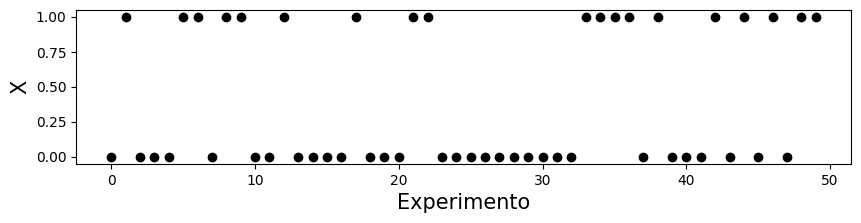

[0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1]


In [ ]:
import numpy as np
from matplotlib import pyplot as plt

np.random.seed(10)

n = 50 # número de experimentos
S = [] # lista que armazena as saídas
p = 0.4 # probabilidade de sucesso
for t in range(0, n):
  # gera uma saída: 0 ou 1
  if(np.random.uniform() < p):
    s = 1
  else:
    s = 0

  S.append(s)

plt.figure(figsize=(10,2))
plt.plot(range(0,n), S, 'ko')
plt.xlabel("Experimento", fontsize=15)
plt.ylabel("X", fontsize=15)
plt.show()
print(S)

### Distribuição Binomial

Seja $X$ uma variável aleatória baseada em $n$ repetições de um processo de Bernoulli. Então a probabilidade de obtermos $k$ sucessos em $n$ repetições é dada por:

$$P(X = k) = \binom{n}{k} p^k (1 - p)^{n-k}, \quad k = 0, 1, 2, \dots, n$$

onde

$$C_k^n = \binom{n}{k} = \frac{n!}{(n - k)!k!}$$

é uma combinação de $n$ elementos tomados de $k$ em $k$.

Se $X$ é uma variável aleatória com distribuição binomial e parâmetros $n$ e $p$, então:

$$E[X] = np$$

$$V[X] = np(1 - p)$$

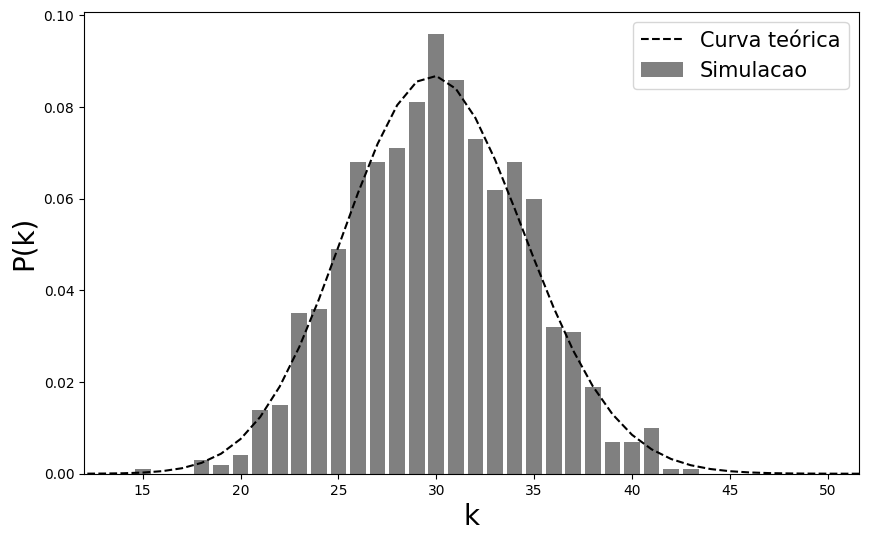

In [ ]:
from matplotlib import pyplot as plt
import numpy as np
from scipy.stats import binom
import math
np.random.seed(42)

n = 100 # numero de lancamentos
p = 0.3 # probabilidade de sair cara
Pk = np.zeros(n)
vk = np.arange(0, n)
ns = 1000 # numero de simulacoes
# simula a distribuicao binomial
for j in range(0,ns):
  S = 0 # numero de sucessos
  for i in range(0, n):
    if(np.random.uniform() <= p): # se sair um sucesso
      S = S + 1
  Pk[S] = Pk[S] + 1

Pk= Pk/sum(Pk) # normaliza a distribuicao de probabilidade

plt.figure(figsize=(10,6))
plt.xlim(0.8*np.min(vk[Pk>0]), 1.2*np.max(vk[Pk>0]))

plt.bar(vk, Pk, color = 'gray', label = 'Simulacao')
# mostra a curva teorica
Pkt = np.zeros(n+1) # valores teóricos da probabilidade
vkt = np.arange(0,n+1) # variação em k
for k in range(0,n+1): # varia de 0 ate n
    C = (math.factorial(n)/(math.factorial(n-k)*math.factorial(k)))
    Pkt[k] = C*(p**k)*(1-p)**(n-k)
plt.plot(vkt, Pkt, color ='black', linestyle = 'dashed', label='Curva teórica')
plt.xlabel('k', fontsize = 20)
plt.ylabel('P(k)',fontsize = 20)
plt.legend(fontsize = 15)
plt.savefig('binomial.svg')
plt.show(True)

### Distribuição de Poisson

Uma variável aleatória discreta $X$ segue o **modelo de Poisson** com taxa $\lambda > 0$ se a sua probabilidade é dada por:

$$P(X = k) = \frac{e^{-\lambda} \lambda^k}{k!}, \quad k = 0, 1, 2, \dots$$

Onde:
* $\lambda$ é a taxa média de ocorrência por unidade (tempo, área, etc).
* $E[X] = \lambda$
* $V[X] = \lambda$

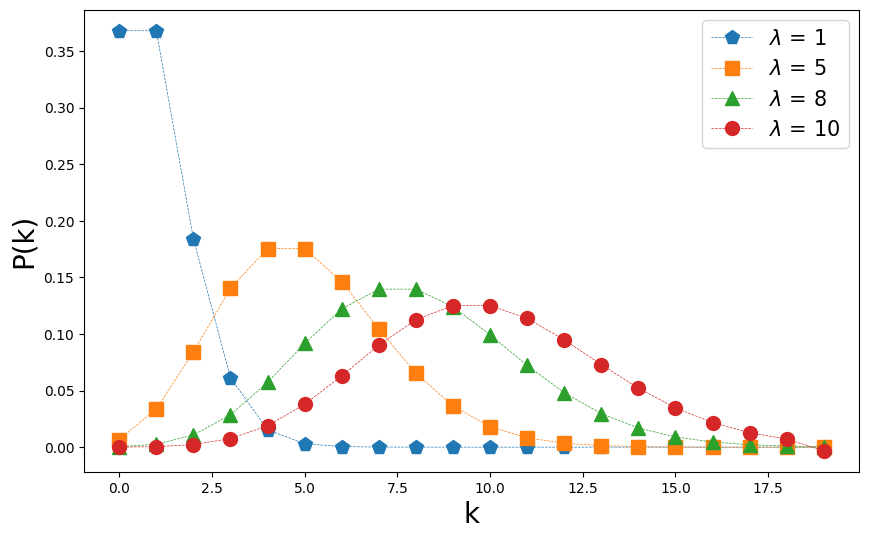

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import math as math
kmax = 20 # valor máximo de k
plt.figure(figsize=(10,6))
vlb = [1,5,8,10] # lambdas
markers = ["o", "^", "s", "p"] # símbolos no gráfico
for lbd in vlb:
    px = []
    for k in np.arange(0,kmax):
        px.append((np.exp(-lbd)*lbd**k)/math.factorial(k))
    plt.plot(np.arange(0,kmax), px, marker=markers.pop(), markersize=10,
             linewidth=0.5,linestyle='dashed',
             label=r'$\lambda$ = '+str(lbd))
    plt.xlabel('k', fontsize = 20)
    plt.ylabel('P(k)',fontsize = 20)
plt.legend(fontsize = 15)
plt.show(True)

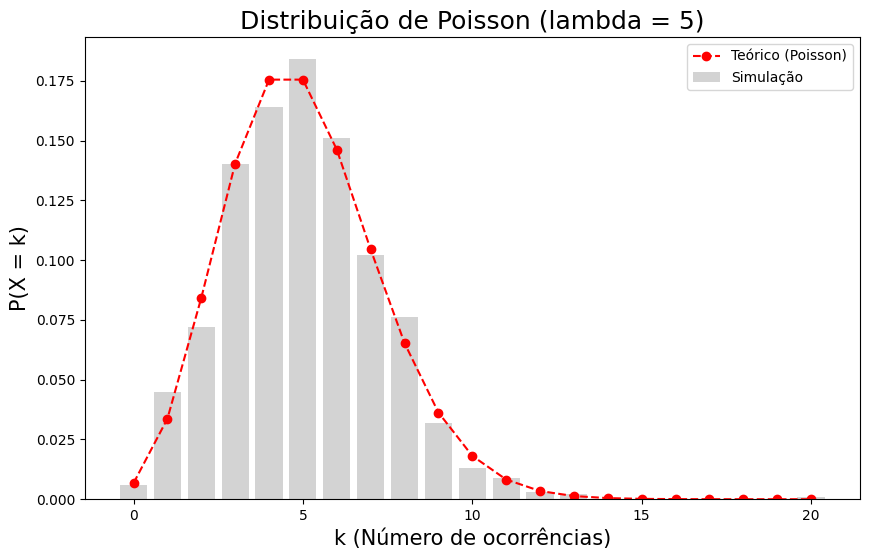

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import math
from scipy.stats import poisson

lmbda = 5  # taxa lambda
ns = 1000  # número de simulações

X = np.random.poisson(lmbda, ns)

values, counts = np.unique(X, return_counts=True)
Pk = counts / ns

# Curva teórica
vkt = np.arange(0, np.max(X) + 1)
Pkt = [ (np.exp(-lmbda) * (lmbda**k)) / math.factorial(k) for k in vkt ]

# Visualização
plt.figure(figsize=(10, 6))
plt.bar(values, Pk, color='lightgray', label='Simulação')
plt.plot(vkt, Pkt, 'ro--', label='Teórico (Poisson)')
plt.xlabel('k (Número de ocorrências)', fontsize=15)
plt.ylabel('P(X = k)', fontsize=15)
plt.title(f'Distribuição de Poisson (lambda = {lmbda})', fontsize=18)
plt.legend()
plt.show()


Seja $X$ uma variável aleatória com distribuição de Poisson. Então,

$$E[X] = \lambda$$

$$V(X) = \lambda$$


### Aproximação da Binomial pela Poisson

Quando o número de ensaios $n$ é grande ($n \to \infty$) e a probabilidade de sucesso $p$ é pequena ($p \to 0$), de modo que o produto $\lambda = np$ permaneça constante, a distribuição Binomial converge para a distribuição de Poisson:

$$\lim_{n \to \infty} \binom{n}{k} p^k (1 - p)^{n-k} = \frac{e^{-\lambda} \lambda^k}{k!}, \quad k = 0, 1, 2, \dots$$

Essa aproximação é geralmente considerada boa quando $n \geq 20$ e $p \leq 0.05$, ou $n \geq 100$ e $np \leq 10$.

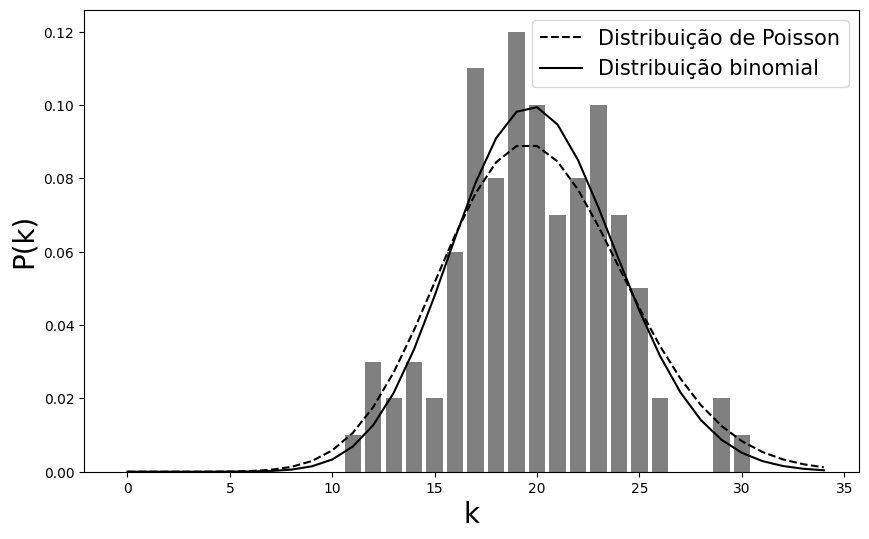

In [ ]:
import numpy as np
from scipy.stats import poisson, binom
from matplotlib import pyplot as plt
np.random.seed(101)

N = 100 # número de vértices
lbd = 20 # número médio de conexões
p = lbd/(N-1) # probabilidade de conectar dois vértices
# cria a matriz de adjacência
A = np.zeros((N,N))
for i in range(0,N):
    for j in range(i+1,N):
        if np.random.uniform() <= p:
            # conecta os vértices i e j
            A[i,j] = 1
            A[j,i] = 1
# lista com o número de conexões de cada vértice
vk = np.sum(A, axis = 0,dtype = np.uint8)
# armazena a distribuição de probabilidade
Pk = np.zeros(int(np.max(vk)+1))
for k in vk:
    Pk[k] = Pk[k]+1
Pk = Pk/np.sum(Pk)

# mostra a distribuição de probabilidade
plt.figure(figsize=(10,6))
plt.bar(np.arange(0,np.max(vk)+1), Pk, color = 'gray')
plt.xlabel('k', fontsize = 20)
plt.ylabel('P(k)',fontsize = 20)

# Mostra a distribuição teórica de Poisson
x = np.arange(0,np.max(vk)+5)
px = poisson((N-1)*p)
plt.plot(x,px.pmf(x), '--', color ='black',
         label='Distribuição de Poisson')

# Mostra a distribuição teórica binomial
pb = binom((N-1),p)
plt.plot(x,pb.pmf(x), '-', color = 'black',
         label='Distribuição binomial')
plt.legend(fontsize = 15)
plt.show(True)

### Distribuição Geométrica

Dizemos que a variável aleatória discreta $X$ segue uma **distribuição geométrica** se ela representa o número de tentativas até o primeiro sucesso em ensaios de Bernoulli independentes, com probabilidade de sucesso $p$:

$$P(X = k) = p(1 - p)^{k-1}, \quad k = 1, 2, \dots$$

**Propriedades:**

Se $X$ é uma variável aleatória com distribuição geométrica, então:

$$E[X] = \frac{1}{p}$$

$$V(X) = \frac{1 - p}{p^2}$$

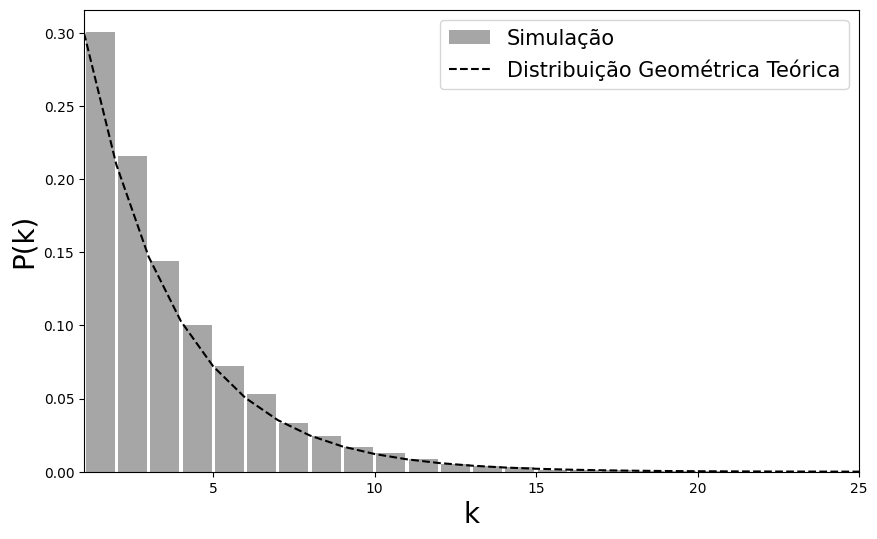

In [ ]:
from matplotlib import pyplot as plt
import numpy as np
from scipy.stats import geom
np.random.seed(10)

p = 0.3 # probabilidade de um sucesso
X = [] # Armazena o número de experimentos
ns = 10000 # número de simulações
for i in range(0,ns):# para ns simulações
    k = 0 # número de experimentos
    s = False # variável que indica uma falha
    while s == False: # enquanto não sair um sucesso
        r = np.random.uniform() # sorteia um numero entre 0 e 1
        if(r <= p): # se for um sucesso
            s = True # indica um sucesso
        k = k + 1 # incrementa o número de experimentos
    X.append(k) # guarda o número de experimentos

k = np.arange(0, np.max(X))
# mostra os resultados da simulação
plt.figure(figsize=(10,6))
count, bins, ignored = plt.hist(X, bins=k, density=True,
                                color='gray',alpha=0.7,
                                rwidth=0.9, label='Simulação')
plt.xlabel('k', fontsize = 20)
plt.ylabel('P(k)',fontsize = 20)

# mostra a distribuicao teórica
x = np.arange(1,np.max(k)+5)
px = geom(p)
plt.plot(x,px.pmf(x), '--', color ='black',
         label='Distribuição Geométrica Teórica')
plt.xlim(1,max(x))
plt.legend(fontsize =15)
plt.show(True)

### Distribuição Binomial Negativa

Seja $X$ o número de repetições necessárias a fim de que ocorram exatamente $r$ sucessos, de modo que o $r$-ésimo sucesso ocorra na $k$-ésima tentativa. A probabilidade é dada por:

$$P(X = k) = \binom{k - 1}{r - 1} p^r (1 - p)^{k-r}, \quad k = r, r + 1, \dots$$

**Propriedades:**
* $E[X] = \frac{r}{p}$
* $V(X) = \frac{r(1-p)}{p^2}$

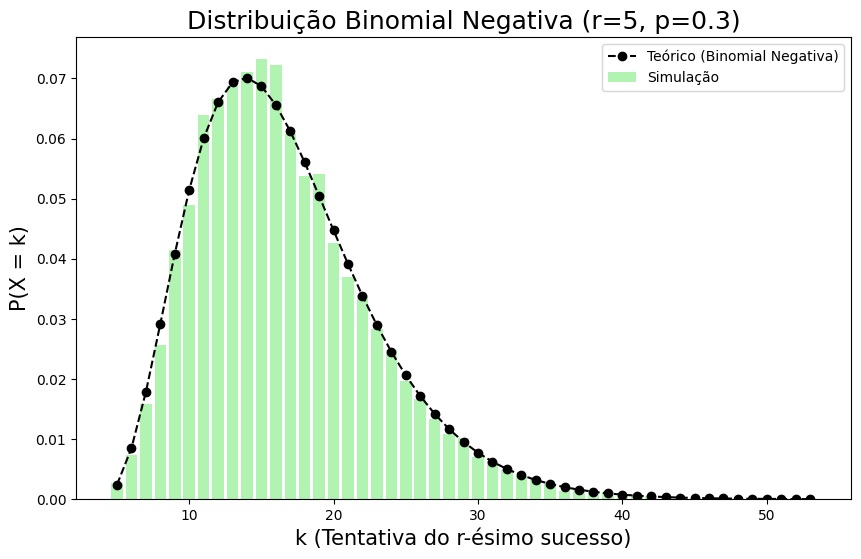

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import nbinom

np.random.seed(42)
r = 5    # número de sucessos desejados
p = 0.3  # probabilidade de sucesso
ns = 10000

# Simulação: scipy usa 'n' como número de falhas, então somamos r para ter o número total de tentativas k
X = np.random.negative_binomial(r, p, ns) + r

values, counts = np.unique(X, return_counts=True)
Pk = counts / ns

# Curva teórica
vkt = np.arange(r, np.max(X) + 1)
# nbinom.pmf no scipy: k é o número de falhas (k_total - r)
Pkt = nbinom.pmf(vkt - r, r, p)

plt.figure(figsize=(10, 6))
plt.bar(values, Pk, color='lightgreen', alpha=0.7, label='Simulação')
plt.plot(vkt, Pkt, 'ko--', label='Teórico (Binomial Negativa)')
plt.xlabel('k (Tentativa do r-ésimo sucesso)', fontsize=15)
plt.ylabel('P(X = k)', fontsize=15)
plt.title(f'Distribuição Binomial Negativa (r={r}, p={p})', fontsize=18)
plt.legend()
plt.show()